# Exploratory Data Analysis on County-Level Corn Yield Dataset

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)

## Load Dataset

In [3]:
df = pd.read_csv('../data/processed/corn_belt_yield_weather_soil.csv', dtype={"fips":str, "state_ansi":str, "county_ansi":str})

## Basic Data Inspection

In [4]:
df.head()

,state_name,state_alpha,state_ansi,county_ansi,fips,county_name,year,short_desc,unit_desc,statisticcat_desc,...,vp_mean_pa_m12,sand_pct_0_30cm,silt_pct_0_30cm,clay_pct_0_30cm,organic_matter_pct_0_30cm,ph_0_30cm,bulk_density_g_cm3_0_30cm,ksat_um_s_0_30cm,available_water_storage_cm_0_100cm,slope_pct
0,ILLINOIS,IL,17,11,17011,BUREAU,2025,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,357.549355,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
1,ILLINOIS,IL,17,11,17011,BUREAU,2024,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,462.975000,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
2,ILLINOIS,IL,17,11,17011,BUREAU,2023,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,614.017097,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
3,ILLINOIS,IL,17,11,17011,BUREAU,2022,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,393.786774,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
4,ILLINOIS,IL,17,11,17011,BUREAU,2021,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,504.136452,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624


In [5]:
df.tail()

,state_name,state_alpha,state_ansi,county_ansi,fips,county_name,year,short_desc,unit_desc,statisticcat_desc,...,vp_mean_pa_m12,sand_pct_0_30cm,silt_pct_0_30cm,clay_pct_0_30cm,organic_matter_pct_0_30cm,ph_0_30cm,bulk_density_g_cm3_0_30cm,ksat_um_s_0_30cm,available_water_storage_cm_0_100cm,slope_pct
24639,WISCONSIN,WI,55,133,55133,WAUKESHA,2004,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,349.899333,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936
24640,WISCONSIN,WI,55,133,55133,WAUKESHA,2003,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,397.107097,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936
24641,WISCONSIN,WI,55,133,55133,WAUKESHA,2002,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,360.261935,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936
24642,WISCONSIN,WI,55,133,55133,WAUKESHA,2001,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,449.862581,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936
24643,WISCONSIN,WI,55,133,55133,WAUKESHA,2000,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,192.104333,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936


In [6]:
df.shape

(24644, 106)

In [7]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24644 entries, 0 to 24643
Data columns (total 106 columns):
 #    Column                              Dtype  
---   ------                              -----  
 0    state_name                          object 
 1    state_alpha                         object 
 2    state_ansi                          object 
 3    county_ansi                         object 
 4    fips                                object 
 5    county_name                         object 
 6    year                                int64  
 7    short_desc                          object 
 8    unit_desc                           object 
 9    statisticcat_desc                   object 
 10   Value                               float64
 11   latitude                            float64
 12   longitude                           float64
 13   prcp_total_mm_m01                   float64
 14   prcp_total_mm_m02                   float64
 15   prcp_total_mm_m03                 

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,24644.0,2011.815533,7.443268,2000.000000,2005.000000,2011.000000,2018.000000,2025.000000
Value,24644.0,147.829005,38.241255,0.000000,124.000000,151.800000,175.300000,253.600000
latitude,24644.0,41.299657,2.812696,36.211400,39.059800,40.988000,43.345900,48.814900
longitude,24644.0,-91.543901,5.702835,-103.846600,-96.177900,-91.479300,-86.446200,-80.748200
prcp_total_mm_m01,24644.0,46.268875,42.391356,0.000000,14.850000,32.025000,66.360000,283.480000
prcp_total_mm_m02,24644.0,48.823535,43.909309,0.000000,17.707500,36.840000,66.080000,343.800000
prcp_total_mm_m03,24644.0,68.422388,47.886767,0.000000,32.010000,60.490000,93.090000,444.310000
prcp_total_mm_m04,24644.0,95.190592,54.840617,0.000000,57.330000,87.870000,121.957500,493.550000
prcp_total_mm_m05,24644.0,117.017343,57.939928,0.000000,74.820000,110.435000,149.892500,479.270000
prcp_total_mm_m06,24644.0,116.753259,61.911087,0.000000,72.290000,106.540000,149.635000,552.690000


In [9]:
df.describe(include='object').T

,count,unique,top,freq
state_name,24644,13,IOWA,2470
state_alpha,24644,13,IA,2470
state_ansi,24644,13,19,2470
county_ansi,24644,122,15,315
fips,24644,1124,17011,26
county_name,24644,704,JACKSON,231
short_desc,24644,1,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",24644
unit_desc,24644,1,BU / ACRE,24644
statisticcat_desc,24644,1,YIELD,24644


The Corn Yield (`Value`) has an average of `147.829005` bushels per acre. The median corn yield is `151.8` bushels per acre. The range of yield is from `0` to `253.6` bushels per acre. The zero values will be investigated in the data quality section. The `short_desc`, `unit_desc`, and `statisticcat_desc` have a unique value of `1`. This shows that the records consistently show the corn yield in bushels per acre. 

In [10]:
df['fips'].nunique()

1124

In [11]:
df['state_alpha'].unique()

array(['IL', 'IN', 'IA', 'KS', 'KY', 'MI', 'MN', 'MO', 'NE', 'ND', 'OH',
       'SD', 'WI'], dtype=object)

In [12]:
df['state_alpha'].nunique()

13

In [13]:
df['year'].min()

2000

In [14]:
df['year'].max()

2025

There are `24,644` rows and `106` columns in the dataset. There are `1124` unique counties across `13` states. The states include `IL`, `IN`, `IA`, `KS`, `KY`, `MI`, `MN`, `MO`, `NE`, `ND`, `OH`, `SD`, and `WI`. The dataset collects corn yield, county weather data, and soil data from each of the states' counties from `2000` to `2025`.

## Checking for Data Quality (Missing Values and Duplicates)

In [15]:
# Missing values
df.isnull().sum()

state_name                            0
state_alpha                           0
state_ansi                            0
county_ansi                           0
fips                                  0
county_name                           0
year                                  0
short_desc                            0
unit_desc                             0
statisticcat_desc                     0
Value                                 0
latitude                              0
longitude                             0
prcp_total_mm_m01                     0
prcp_total_mm_m02                     0
prcp_total_mm_m03                     0
prcp_total_mm_m04                     0
prcp_total_mm_m05                     0
prcp_total_mm_m06                     0
prcp_total_mm_m07                     0
prcp_total_mm_m08                     0
prcp_total_mm_m09                     0
prcp_total_mm_m10                     0
prcp_total_mm_m11                     0
prcp_total_mm_m12                     0


In [16]:
# duplicated rows
df.duplicated().sum()

0

In [17]:
df.duplicated(subset=['fips', 'year']).sum()

0

Check target variable `yield`

In [18]:
# Any negative Values?
(df['Value'] < 0).sum()

0

In [19]:
df['Value'].min()

0.0

In [20]:
df['Value'].max()

253.6

In [21]:
(df['Value'] == 0).sum()

18

In [22]:
df[df['Value'] == 0][['state_name', 'county_name', 'fips', 'year', 'Value']]

,state_name,county_name,fips,year,Value
11229,MICHIGAN,DELTA,26041,2001,0.0
11236,MICHIGAN,DICKINSON,26043,2003,0.0
11237,MICHIGAN,DICKINSON,26043,2002,0.0
11238,MICHIGAN,MARQUETTE,26103,2007,0.0
11239,MICHIGAN,MARQUETTE,26103,2002,0.0
11451,MICHIGAN,ALCONA,26001,2002,0.0
21765,SOUTH DAKOTA,HARDING,46063,2006,0.0
21766,SOUTH DAKOTA,HARDING,46063,2005,0.0
21769,SOUTH DAKOTA,HARDING,46063,2002,0.0
21771,SOUTH DAKOTA,HARDING,46063,2000,0.0


There are no missing or duplicated rows. There are also no negative values for our target variable `Value`. There is a minimum value of `0` and a maximum value of `253.6`. 

It seems that we have `18` yield values that are equal to `0` from Michigan and South Dakota. 

A manual check of USDA NASS Quick Stats confirmed a reported yield of 0 for Delta County, Michigan, in 2001.

The reason these have zero yield could be that they were just not reported to the USDA NASS.

Paper Citation with Potential Explanation
>Duncan, Hence and Boyer, Christopher N. and Smith, S. Aaron and Park, Eunchun, What Is Driving Non-Reported National Agricultural Statistics Service Yields? (June 01, 2025). Journal of the American Society of Farm Managers and Rural Appraisers, 2025, Available at SSRN: https://ssrn.com/abstract=7395318 or http://dx.doi.org/10.2139/ssrn.7395318

## Explore each category (Corn Yield, Weather, and Soil)

### Yield Columns

In [23]:
yield_df = df[['state_name', 'state_alpha', 'state_ansi', 'county_ansi', 'fips', 'county_name', 'year', 'short_desc', 'unit_desc', 'statisticcat_desc', 'Value']]

In [24]:
yield_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,24644.0,2011.815533,7.443268,2000.0,2005.0,2011.0,2018.0,2025.0
Value,24644.0,147.829005,38.241255,0.0,124.0,151.8,175.3,253.6


In [25]:
yield_df.describe(include='object').T

,count,unique,top,freq
state_name,24644,13,IOWA,2470
state_alpha,24644,13,IA,2470
state_ansi,24644,13,19,2470
county_ansi,24644,122,15,315
fips,24644,1124,17011,26
county_name,24644,704,JACKSON,231
short_desc,24644,1,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",24644
unit_desc,24644,1,BU / ACRE,24644
statisticcat_desc,24644,1,YIELD,24644


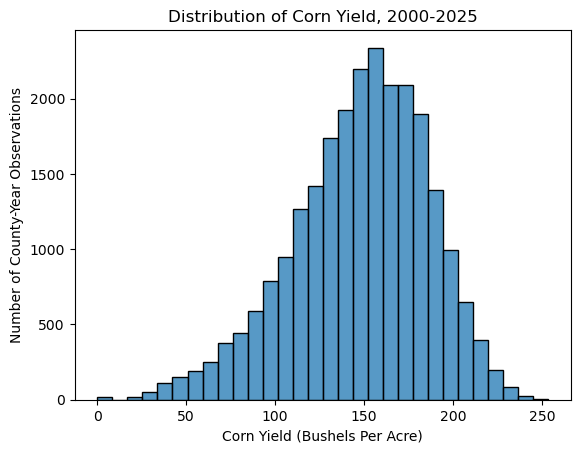

In [26]:
sns.histplot(data=yield_df, x='Value', bins=30)

plt.xlabel('Corn Yield (Bushels Per Acre)')
plt.ylabel('Number of County-Year Observations')
plt.title('Distribution of Corn Yield, 2000-2025')

plt.show()

The corn yields from 2000-2025 have a single peak around 150-160 bushels per acre. Most of the observations are around 100-200 bushels per acre.

There is a little bit of a tail towards the left meaning there is some left skew. 

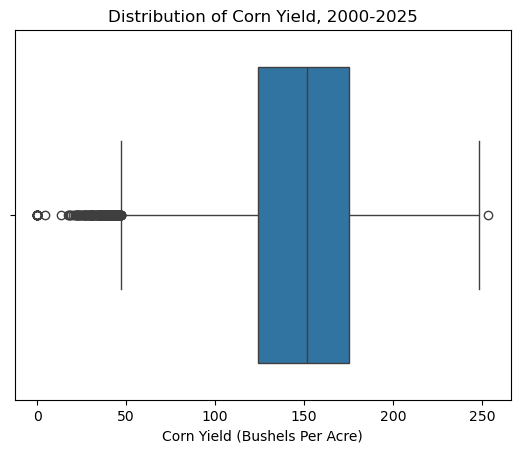

In [27]:
sns.boxplot(data=yield_df, x='Value')

plt.xlabel('Corn Yield (Bushels Per Acre)')
plt.title('Distribution of Corn Yield, 2000-2025')

plt.show()

In [28]:
# Calculate IQR with pd.quantile
q1 = yield_df['Value'].quantile(q=0.25)
q2 = yield_df['Value'].quantile(q=0.5)
q3 = yield_df['Value'].quantile(q=0.75)

iqr = q3 - q1

low_outliers = q1 - (1.5 * iqr)
high_outliers = q3 + (1.5 * iqr)

print(f"Q1: {q1}")
print(f"Q2: {q2}")
print(f"Q3: {q3}")

print(f"Interquartile Range: {iqr:.2f}")
print(f"Low Outliers: {low_outliers:.2f}")
print(f"High Outliers: {high_outliers:.2f}")

Q1: 124.0
Q2: 151.8
Q3: 175.3
Interquartile Range: 51.30
Low Outliers: 47.05
High Outliers: 252.25


The median corn yield is 151.8 bushels per acre. the middle 50% of county year observations fall between 124 and 175.3 bushels per acre which gives an interquartile range of 51.3 bushels per acre.

Calculating the low and high outliers shows that yield below 47.05 and yield higher than 252.25 are potential outliers. There are more low yield outliers on the boxplot which is consistent with the histogram. 

In [29]:
yearly_yield = yield_df.groupby('year')['Value'].agg(['mean', 'median'])
yearly_yield

,mean,median
year,,
2000,127.573596,133.10
2001,126.356777,129.00
2002,112.486555,112.20
2003,125.598224,130.15
2004,145.327767,152.00
2005,132.854632,138.00
2006,135.442746,142.50
2007,136.538797,138.00
2008,141.408949,142.00


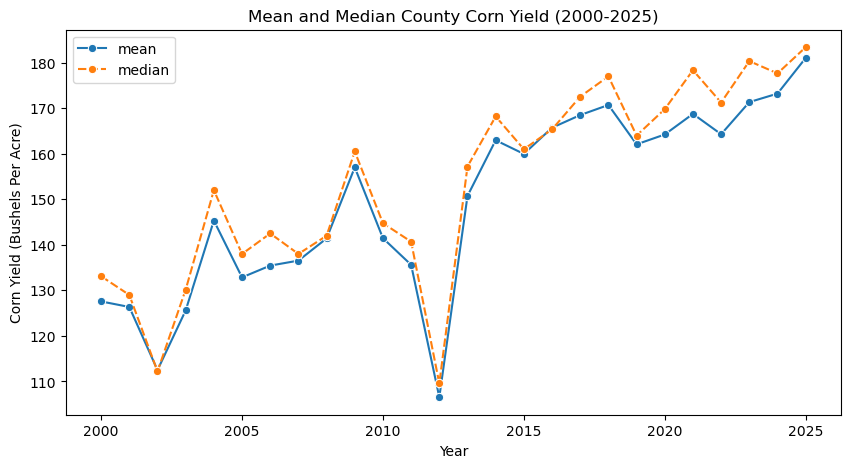

In [30]:
plt.figure(figsize=(10,5))

sns.lineplot(data=yearly_yield, marker='o')

plt.xlabel('Year')
plt.ylabel('Corn Yield (Bushels Per Acre)')
plt.title('Mean and Median County Corn Yield (2000-2025)')
plt.show()

The mean and median county corn yield has increased from 2000 - 2025. There is a big dip in the year 2012. This has the lowest mean and median with 106.53	and 109.55 bushels per acre respectively. This could be because of the drought of 2012, but could be other factors as well. The median is higher than the mean for most of the years. 

In [39]:
state_yield = yield_df.groupby('state_alpha')['Value'].agg(['count', 'mean', 'median'])
state_yield.sort_values('median')

,count,mean,median
state_alpha,,,
ND,1054,106.567362,106.0
KS,2090,120.636555,120.0
SD,1363,118.348863,121.9
MO,1967,133.562176,136.1
MI,1485,136.071246,138.4
KY,2092,139.897562,142.0
WI,1577,147.063475,148.8
OH,2051,152.524281,155.2
MN,1867,158.578575,163.0


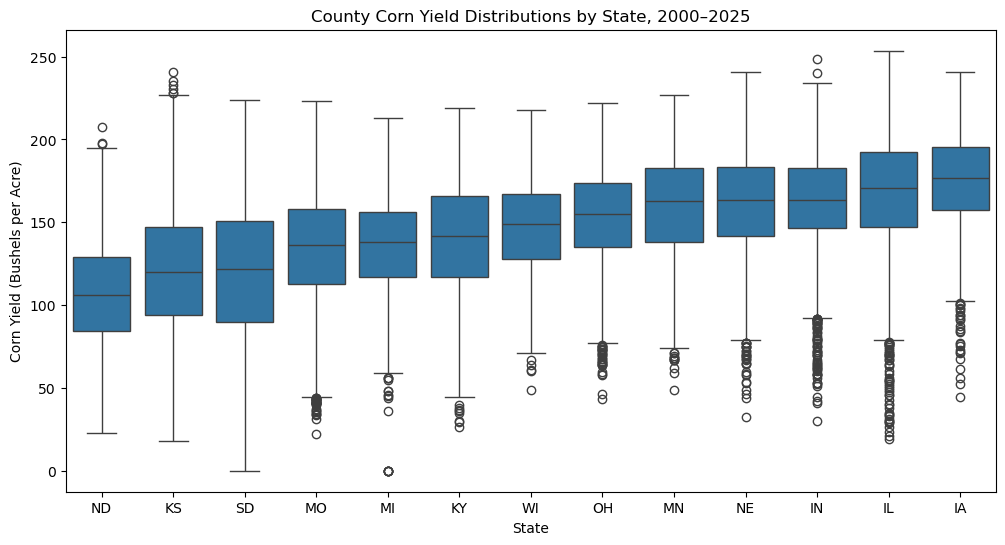

In [40]:
state_order = state_yield.sort_values('median').index

plt.figure(figsize=(12, 6))

sns.boxplot(data=yield_df, x='state_alpha', y='Value', order=state_order)

plt.xlabel('State')
plt.ylabel('Corn Yield (Bushels per Acre)')
plt.title('County Corn Yield Distributions by State, 2000–2025')

plt.show()

The median county corn yeilds across all of the states are different. Iowa has the highest of 176.7 bushels per acres followed by Illinois and Indiana. North Dakota has the lowest median with 106.

Minnesota, Nebraska, and Indiana have all very similar medians from 163 - 163.6 bushels per acre. 

### Weather Columns

In [24]:
weather_df = df[['latitude', 'longitude', 'prcp_total_mm_m01', 'prcp_total_mm_m02', 'prcp_total_mm_m03', 'prcp_total_mm_m04', 'prcp_total_mm_m06', 'prcp_total_mm_m05', 'prcp_total_mm_m07', 'prcp_total_mm_m08', 'prcp_total_mm_m09', 'prcp_total_mm_m10', 'prcp_total_mm_m11', 'prcp_total_mm_m12', 'radiation_total_mj_m2_m01', 'radiation_total_mj_m2_m02', 'radiation_total_mj_m2_m03', 'radiation_total_mj_m2_m04', 'radiation_total_mj_m2_m05', 'radiation_total_mj_m2_m06', 'radiation_total_mj_m2_m07', 'radiation_total_mj_m2_m08', 'radiation_total_mj_m2_m09', 'radiation_total_mj_m2_m10', 'radiation_total_mj_m2_m11', 'radiation_total_mj_m2_m12', 'dayl_mean_s_m01', 'dayl_mean_s_m02', 'dayl_mean_s_m03', 'dayl_mean_s_m04', 'dayl_mean_s_m05', 'dayl_mean_s_m06', 'dayl_mean_s_m07', 'dayl_mean_s_m08', 'dayl_mean_s_m09', 'dayl_mean_s_m10', 'dayl_mean_s_m11', 'dayl_mean_s_m12', 'swe_mean_kg_m2_m01', 'swe_mean_kg_m2_m02', 'swe_mean_kg_m2_m03', 'swe_mean_kg_m2_m04', 'swe_mean_kg_m2_m05', 'swe_mean_kg_m2_m06', 'swe_mean_kg_m2_m07', 'swe_mean_kg_m2_m08', 'swe_mean_kg_m2_m09', 'swe_mean_kg_m2_m10', 'swe_mean_kg_m2_m11', 'swe_mean_kg_m2_m12', 'tmax_mean_c_m01', 'tmax_mean_c_m02', 'tmax_mean_c_m03', 'tmax_mean_c_m04', 'tmax_mean_c_m05', 'tmax_mean_c_m06', 'tmax_mean_c_m07', 'tmax_mean_c_m08', 'tmax_mean_c_m09', 'tmax_mean_c_m10', 'tmax_mean_c_m11', 'tmax_mean_c_m12', 'tmin_mean_c_m01', 'tmin_mean_c_m02', 'tmin_mean_c_m03', 'tmin_mean_c_m04', 'tmin_mean_c_m05', 'tmin_mean_c_m06', 'tmin_mean_c_m07', 'tmin_mean_c_m08', 'tmin_mean_c_m09', 'tmin_mean_c_m10', 'tmin_mean_c_m11', 'tmin_mean_c_m12', 'vp_mean_pa_m01', 'vp_mean_pa_m02', 'vp_mean_pa_m03', 'vp_mean_pa_m04', 'vp_mean_pa_m05', 'vp_mean_pa_m06', 'vp_mean_pa_m07', 'vp_mean_pa_m08', 'vp_mean_pa_m09', 'vp_mean_pa_m10', 'vp_mean_pa_m11', 'vp_mean_pa_m12']]

In [25]:
weather_df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,24644.0,41.299657,2.812696,36.211400,39.059800,40.988000,43.345900,48.814900
longitude,24644.0,-91.543901,5.702835,-103.846600,-96.177900,-91.479300,-86.446200,-80.748200
prcp_total_mm_m01,24644.0,46.268875,42.391356,0.000000,14.850000,32.025000,66.360000,283.480000
prcp_total_mm_m02,24644.0,48.823535,43.909309,0.000000,17.707500,36.840000,66.080000,343.800000
prcp_total_mm_m03,24644.0,68.422388,47.886767,0.000000,32.010000,60.490000,93.090000,444.310000
prcp_total_mm_m04,24644.0,95.190592,54.840617,0.000000,57.330000,87.870000,121.957500,493.550000
prcp_total_mm_m06,24644.0,116.753259,61.911087,0.000000,72.290000,106.540000,149.635000,552.690000
prcp_total_mm_m05,24644.0,117.017343,57.939928,0.000000,74.820000,110.435000,149.892500,479.270000
prcp_total_mm_m07,24644.0,103.169191,56.613045,0.000000,62.047500,95.170000,135.310000,467.300000
prcp_total_mm_m08,24644.0,95.501507,56.383040,0.000000,54.750000,86.880000,125.650000,525.070000


### Soil Columns

In [26]:
soil_df = df[['sand_pct_0_30cm', 'silt_pct_0_30cm', 'clay_pct_0_30cm', 'organic_matter_pct_0_30cm', 'ph_0_30cm', 'bulk_density_g_cm3_0_30cm', 'ksat_um_s_0_30cm', 'available_water_storage_cm_0_100cm', 'slope_pct']]

In [27]:
soil_df.describe().T

,count,mean,std,min,25%,50%,75%,max
sand_pct_0_30cm,24644.0,26.783256,18.329489,5.245822,13.336265,21.030298,33.208620,93.898612
silt_pct_0_30cm,24644.0,49.765449,14.274226,2.790688,40.588564,53.577563,60.255602,73.079272
clay_pct_0_30cm,24644.0,23.190775,6.986131,3.295454,19.967875,23.714925,27.781096,55.165325
organic_matter_pct_0_30cm,24644.0,3.809710,3.488993,0.661647,1.864559,2.611190,4.088629,44.840709
ph_0_30cm,24644.0,6.395108,0.548662,4.877296,6.082073,6.377983,6.720624,7.653986
bulk_density_g_cm3_0_30cm,24644.0,1.370239,0.067411,0.759382,1.340060,1.376267,1.410552,1.580268
ksat_um_s_0_30cm,24644.0,15.211793,15.742705,1.619028,7.146214,9.407886,15.001633,119.688843
available_water_storage_cm_0_100cm,24644.0,15.896718,2.538295,6.550572,14.355450,16.289502,17.712906,29.221872
slope_pct,24644.0,6.645935,5.456184,0.431607,2.980599,4.977276,8.252681,42.425691
